In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'160123748018 RE A2 -TANYA.K.docx'
 20250726_155815.jpg
'2nd,3rd memo.pdf'
'4. Conditional Logic in Typescript.gdoc'
'AICTE IDEA Lab Internship.gslides'
 CE.pptx
 Certificates
 Classroom
'Colab Notebooks'
'Colab Notebooks sem 1'
'Colab Notebooks sem 2'
'Copy of WP Class Test - II Important Questions (1).docx'
'Copy of WP Unit - II.docx'
 COURSES
 EXPERIENCE.pdf
'General presentation.gslides'
'iitd tanya.pdf'
'iit ropar'
 kaggle.json
 miniproject
 NPTEL
'PASS BOOK.jpg'
'Personal Docs'
'Prototyping presentation.gslides'
 Screenshot_20251003_172917_LinkedIn.jpg
'signed tanya pan.pdf'
'SIITGOA015B-TANYA KONTISETTY.pdf'
 sleep-disorder-diagnosis-dataset.zip
 Sleep_health_and_lifestyle_dataset.csv
'Statement of Purpose.pdf'
'tanya final resume.pdf'
'TANYA K (CBIT) JAVA.docx'
 tanyakontisetty@gmail.com.jpg
'tanya photo.jpg'
'Untitled document.gdoc'
'WP Unit II Part II.gdoc'


In [ ]:
import pandas as pd

# Example path — replace with your actual one
file_path = '/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv'

data = pd.read_csv(file_path)
data.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
# Drop irrelevant columns
data = data.drop(['Person ID', 'Blood Pressure'], axis=1)

# Handle missing values
data = data.dropna()

# Convert categorical columns to numeric
label_encoders = {}
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

data.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
3,1,28,5,5.9,4,30,8,2,85,3000,1
4,1,28,5,5.9,4,30,8,2,85,3000,1
5,1,28,8,5.9,4,30,8,2,85,3000,0
6,1,29,9,6.3,6,40,7,2,82,3500,0
16,0,29,4,6.5,5,40,7,1,80,4000,1


In [ ]:
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

# Normalize numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_reshaped = np.expand_dims(X_scaled, axis=2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)


In [ ]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [ ]:
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,506 (146.51 KB)

 Trainable params: 37,506 (146.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16,
    verbose=1
)


Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.4897 - loss: 0.6937 - val_accuracy: 0.5484 - val_loss: 0.6497
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5893 - loss: 0.6484 - val_accuracy: 0.8387 - val_loss: 0.6147
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8550 - loss: 0.5967 - val_accuracy: 0.8387 - val_loss: 0.5623
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8300 - loss: 0.5455 - val_accuracy: 0.7742 - val_loss: 0.5122
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9176 - loss: 0.4538 - val_accuracy: 0.7742 - val_loss: 0.4729
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8921 - loss: 0.3760 - val_accuracy: 0.7742 - val_loss: 0.4577
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9053 - loss: 0.3437 - val_accuracy: 0.8065 - val_loss: 0.4558
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9324 - loss: 0.2883 - val_accuracy: 0.7742 - val_loss: 0.4551

In [ ]:
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {acc*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8065 - loss: 0.5629
Test Accuracy: 80.65%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 11, 128)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,514 (252.01 KB)

 Trainable params: 64,514 (252.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.4676 - loss: 0.6917 - val_accuracy: 0.5484 - val_loss: 0.6768
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5541 - loss: 0.6747 - val_accuracy: 0.7742 - val_loss: 0.6533
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7799 - loss: 0.6452 - val_accuracy: 0.7419 - val_loss: 0.6079
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8915 - loss: 0.5715 - val_accuracy: 0.8065 - val_loss: 0.5262
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8827 - loss: 0.4829 - val_accuracy: 0.8065 - val_loss: 0.4635
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9293 - loss: 0.3053 - val_accuracy: 0.8065 - val_loss: 0.4724
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9307 - loss: 0.2994 - val_accuracy: 0.8065 - val_loss: 0.4780
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8676 - loss: 0.3493 - val_accuracy: 0.7742 - val_loss: 0.4500

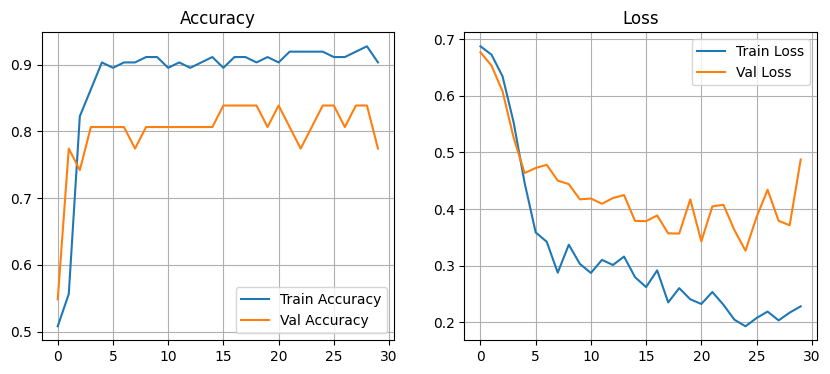

In [ ]:
# ===============================
# 📦 Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ===============================
# 📄 Load Dataset
# ===============================
file_path = '/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv'
data = pd.read_csv(file_path)

# ===============================
# 🧹 Clean & Feature Engineering
# ===============================
# Drop unnecessary columns
data = data.drop(['Person ID', 'Blood Pressure'], axis=1)

# Drop rows with missing values
data = data.dropna()

# Add feature-engineered columns
data['Sleep Efficiency'] = data['Sleep Duration'] * data['Quality of Sleep']
data['Activity_Sleep_Ratio'] = data['Physical Activity Level'] / (data['Sleep Duration'] + 0.1)

# Encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# ===============================
# ⚙️ Split Features & Labels
# ===============================
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

# Scale numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN + LSTM (samples, timesteps, features)
X_reshaped = np.expand_dims(X_scaled, axis=2)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Compute class weights (for imbalance)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ===============================
# 🧠 Build CNN + Stacked LSTM Model
# ===============================
model = Sequential([
    Conv1D(128, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation='softmax')
])

optimizer = Adam(learning_rate=0.0008)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 🏃‍♀️ Train the Model
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ===============================
# 📊 Evaluate Model
# ===============================
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# ===============================
# 📈 Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy'); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 11, 128)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 10, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 5, 128)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,410 (505.51 KB)

 Trainable params: 128,898 (503.51 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.7091 - loss: 0.4964 - val_accuracy: 0.5484 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8890 - loss: 0.4048 - val_accuracy: 0.8387 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9139 - loss: 0.2208 - val_accuracy: 0.8065 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8986 - loss: 0.2495 - val_accuracy: 0.4839 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9150 - loss: 0.2625 - val_accuracy: 0.4839 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 6/60
5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9335 - loss: 0.1551
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9270 - loss: 0.2006 - val_accuracy: 0.4516

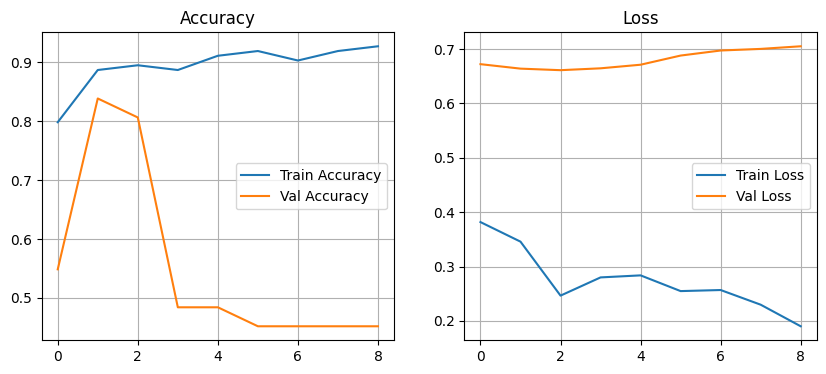

In [ ]:
# ===============================
# 📦 Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ===============================
# 📄 Load Dataset
# ===============================
file_path = '/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv'
data = pd.read_csv(file_path)

# ===============================
# 🧹 Clean & Feature Engineering
# ===============================
data = data.drop(['Person ID', 'Blood Pressure'], axis=1)
data = data.dropna()

# Add feature-engineered columns
data['Sleep Efficiency'] = data['Sleep Duration'] * data['Quality of Sleep']
data['Activity_Sleep_Ratio'] = data['Physical Activity Level'] / (data['Sleep Duration'] + 0.1)

# Encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# ===============================
# ⚙️ Split Features & Labels
# ===============================
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN + LSTM
X_reshaped = np.expand_dims(X_scaled, axis=2)

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ===============================
# 🧠 Build Improved CNN + BiLSTM Model
# ===============================
model = Sequential([
    Conv1D(128, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 🏃‍♀️ Train the Model
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# ===============================
# 📊 Evaluate Model
# ===============================
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# ===============================
# 📈 Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy'); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.grid(True)
plt.show()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 11, 128)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 10, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 5, 128)         │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,410 (505.51 KB)

 Trainable params: 128,898 (503.51 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.7541 - loss: 0.5881 - val_accuracy: 0.5484 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8690 - loss: 0.3380 - val_accuracy: 0.6774 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9144 - loss: 0.2465 - val_accuracy: 0.8710 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9265 - loss: 0.2292 - val_accuracy: 0.8710 - val_loss: 0.6616 - learning_rate: 0.0010
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8700 - loss: 0.3310 - val_accuracy: 0.8065 - val_loss: 0.6557 - learning_rate: 0.0010
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9230 - loss: 0.2265 - val_accuracy: 0.8065 - val_loss: 0.6513 - learning_rate: 0.0010
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9335 - loss: 0.2290 - val_accuracy: 0.806

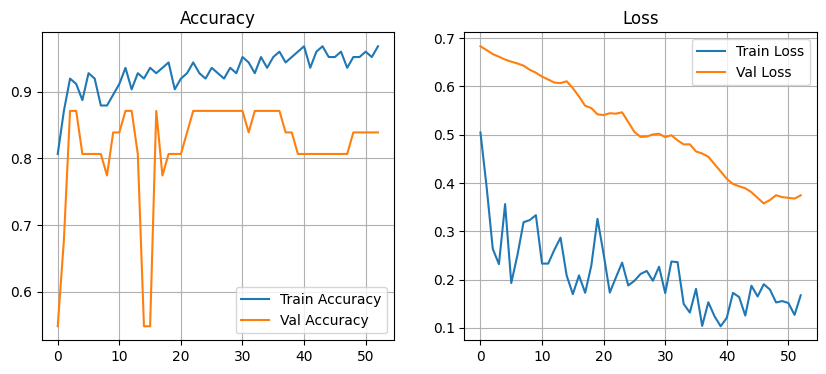

In [ ]:
# ===============================
# 📦 Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ===============================
# 📄 Load Dataset
# ===============================
file_path = '/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv'
data = pd.read_csv(file_path)

# ===============================
# 🧹 Clean & Feature Engineering
# ===============================
data = data.drop(['Person ID', 'Blood Pressure'], axis=1)
data = data.dropna()

# Add feature-engineered columns
data['Sleep Efficiency'] = data['Sleep Duration'] * data['Quality of Sleep']
data['Activity_Sleep_Ratio'] = data['Physical Activity Level'] / (data['Sleep Duration'] + 0.1)

# Encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# ===============================
# ⚙️ Split Features & Labels
# ===============================
X = data.drop('Sleep Disorder', axis=1)
y = data['Sleep Disorder']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN + LSTM
X_reshaped = np.expand_dims(X_scaled, axis=2)

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ===============================
# 🧠 Build Improved CNN + BiLSTM Model
# ===============================
model = Sequential([
    Conv1D(128, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 🏃‍♀️ Train the Model
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=80,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# ===============================
# 📊 Evaluate Model
# ===============================
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# ===============================
# 📈 Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy'); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.grid(True)
plt.show()


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv')

In [ ]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')

# --- Ensure Sleep Disorder is categorical ---
df['Sleep Disorder'] = df['Sleep Disorder'].astype(str)

# --- Numerical features ---
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']

# --- Convert numerical features to numeric ---
df[numerical_features] = df[numerical_features].apply(pd.to_numeric, errors='coerce')

# --- Drop rows with missing values in relevant columns ---
df_clean = df.dropna(subset=numerical_features + ['Sleep Disorder'])

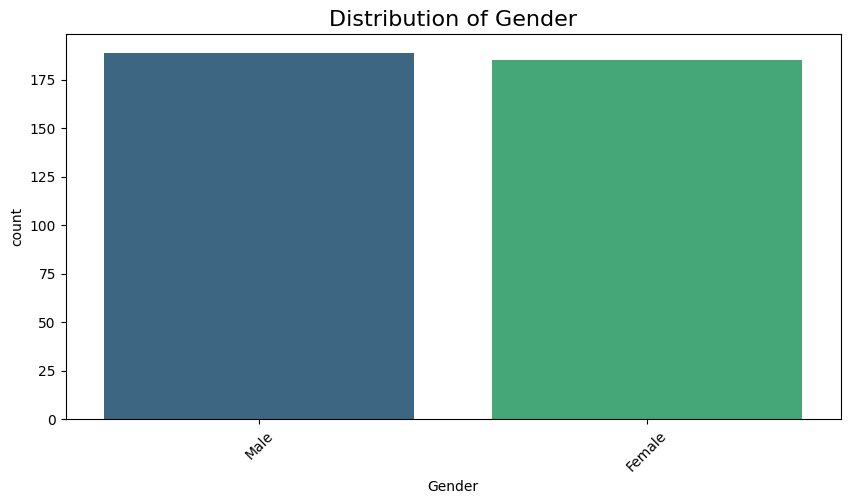

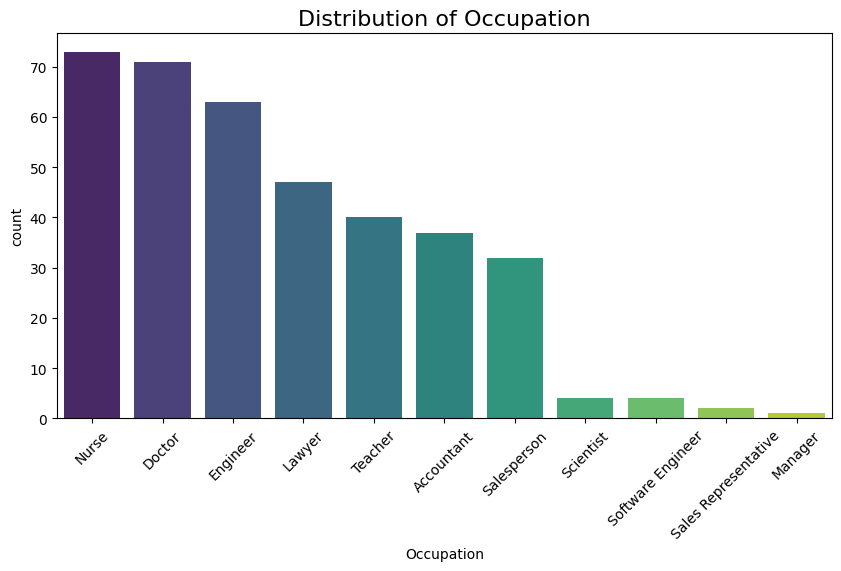

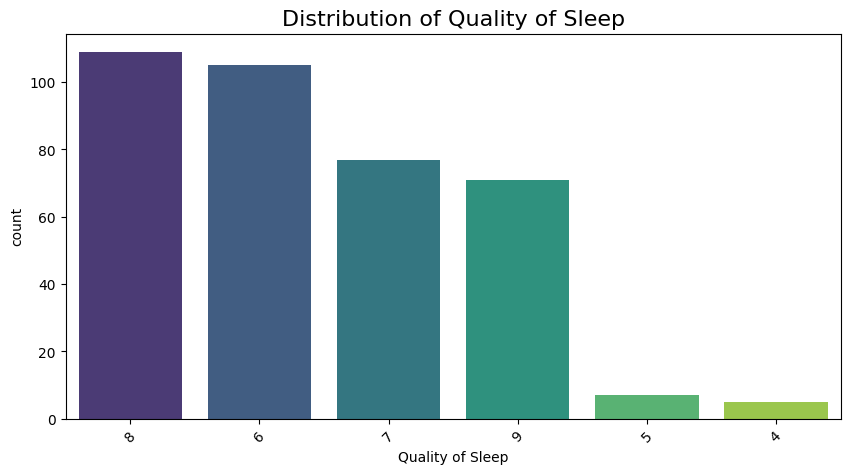

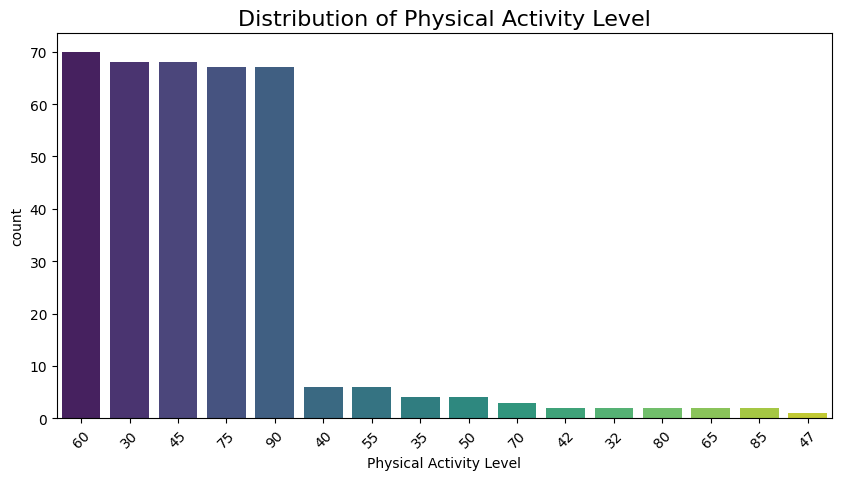

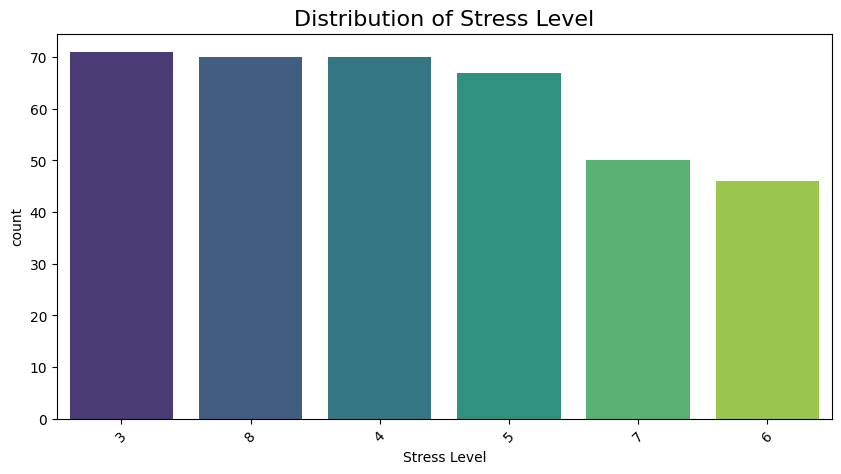

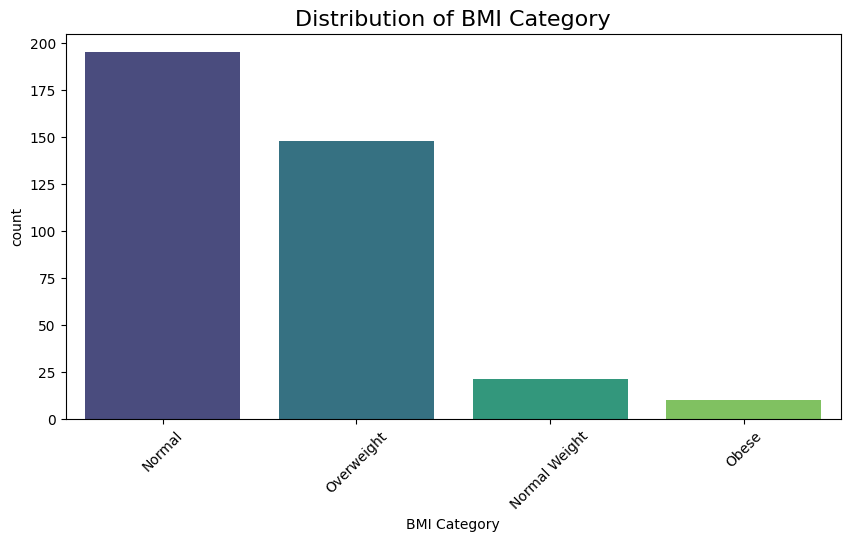

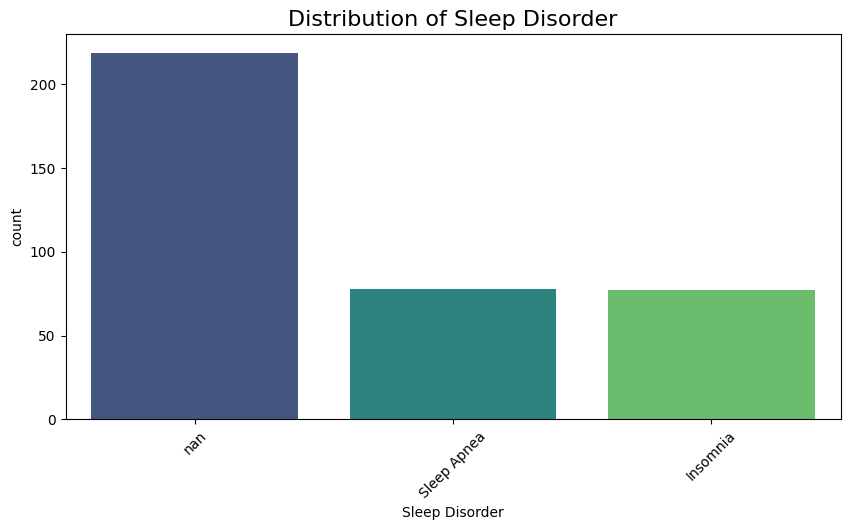

In [ ]:
categorical_features = ['Gender', 'Occupation', 'Quality of Sleep',
                        'Physical Activity Level', 'Stress Level',
                        'BMI Category', 'Sleep Disorder']

for feature in categorical_features:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=feature, palette="viridis", order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()

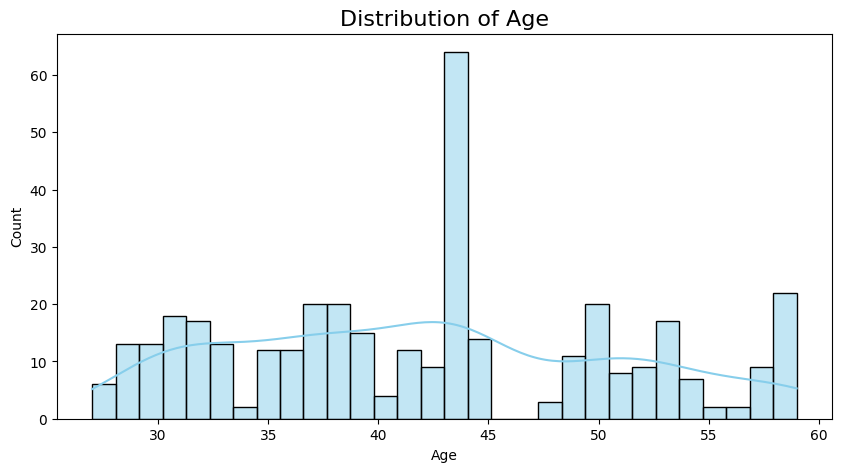

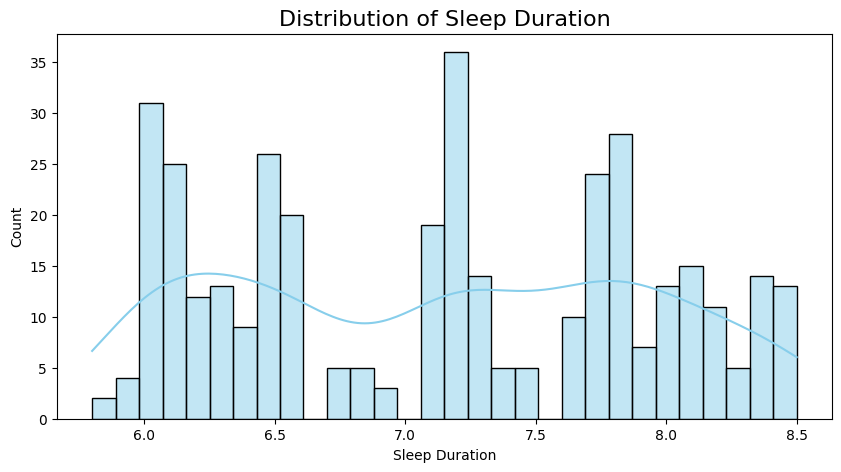

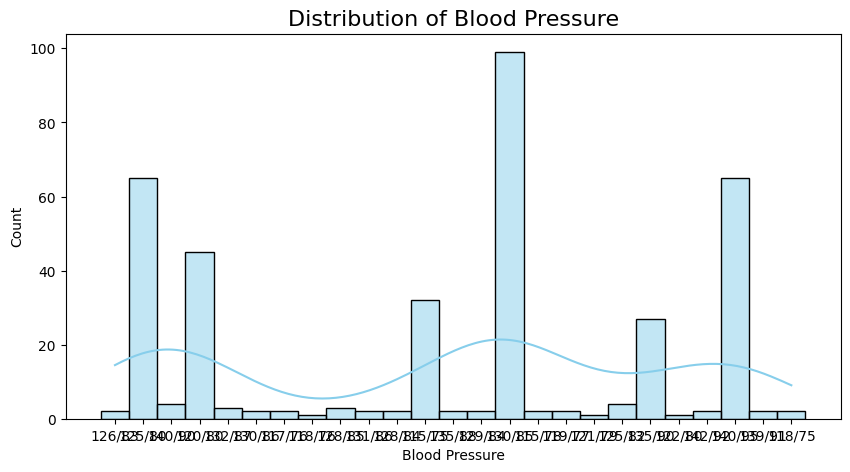

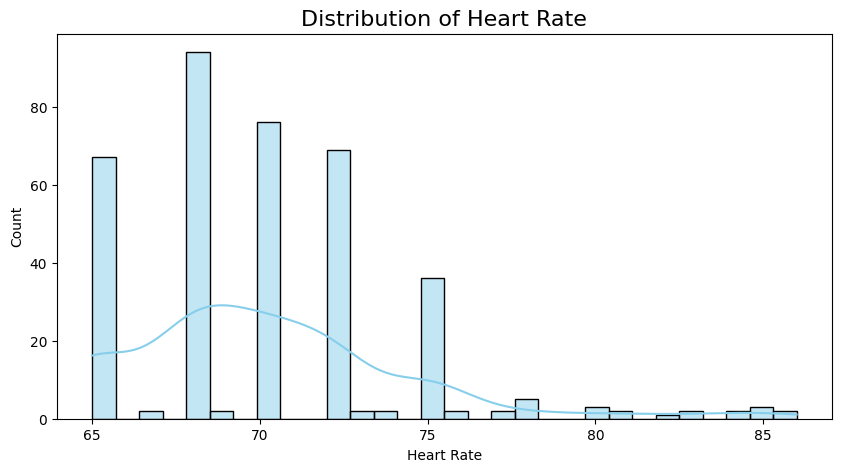

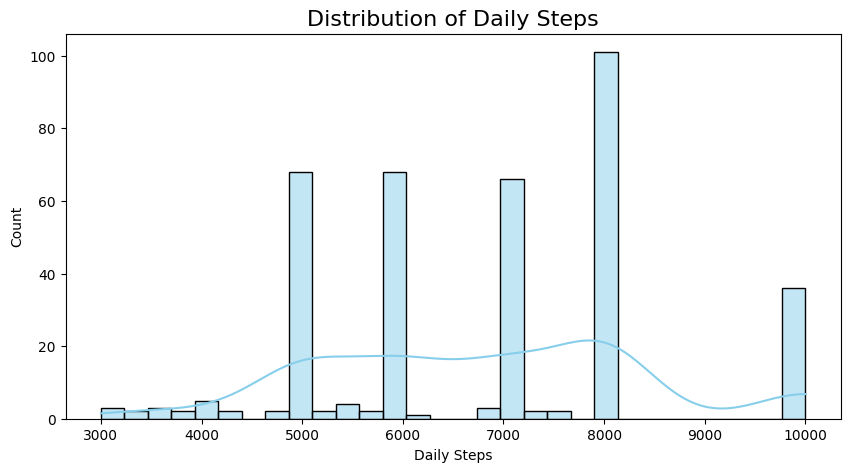

In [ ]:
numerical_features = ['Age', 'Sleep Duration', 'Blood Pressure', 'Heart Rate', 'Daily Steps']

for feature in numerical_features:
    plt.figure(figsize=(10,5))
    sns.histplot(df[feature], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.show()

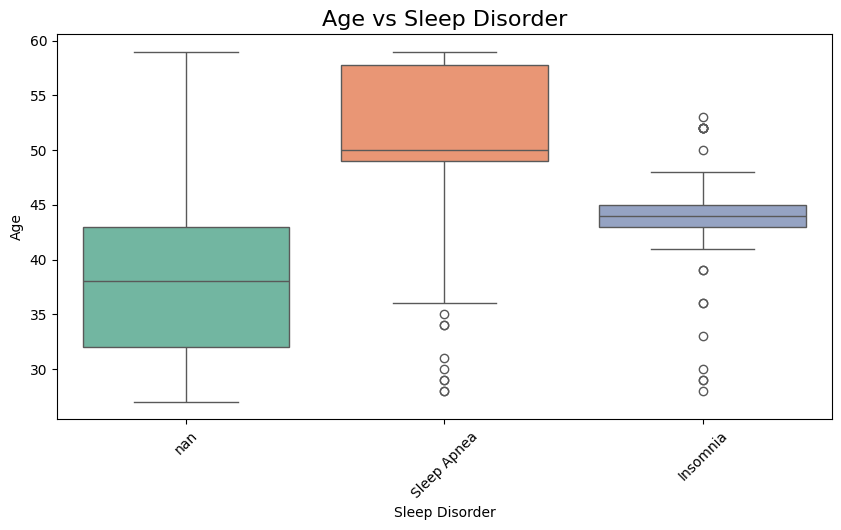

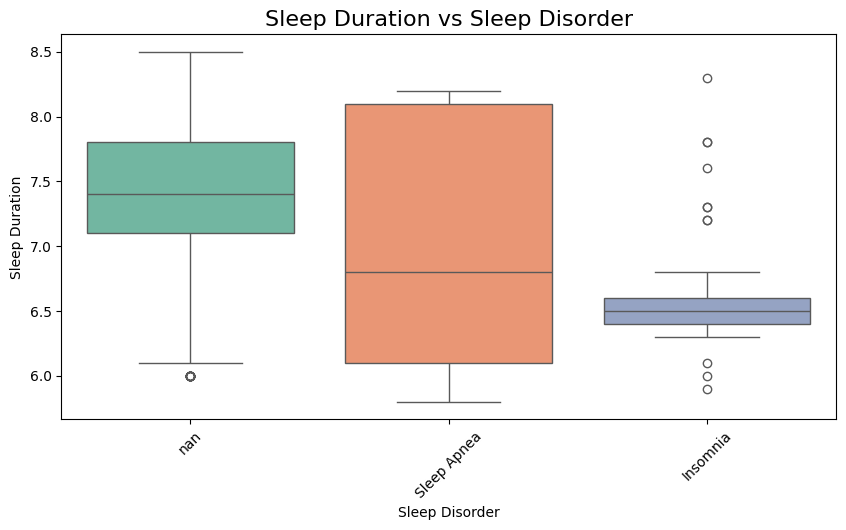

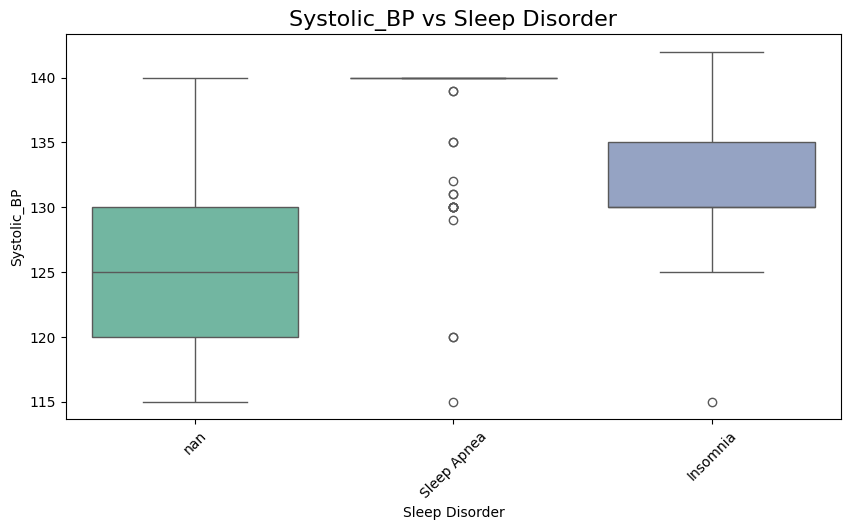

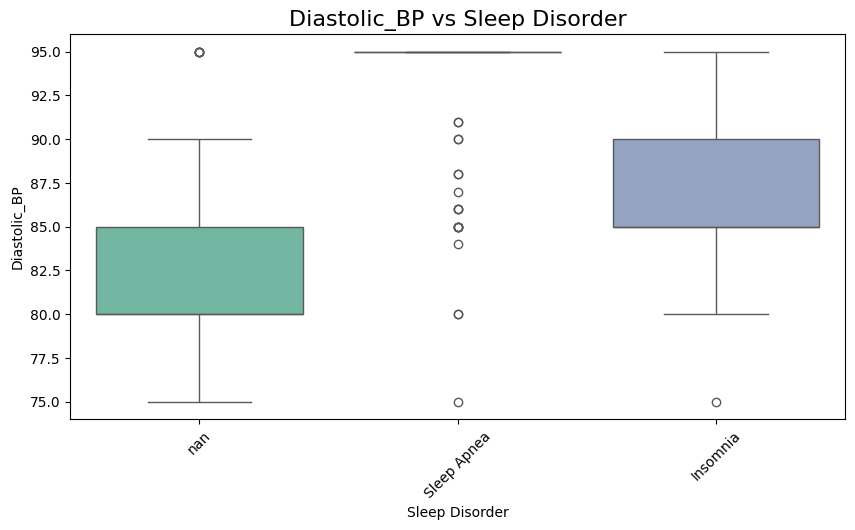

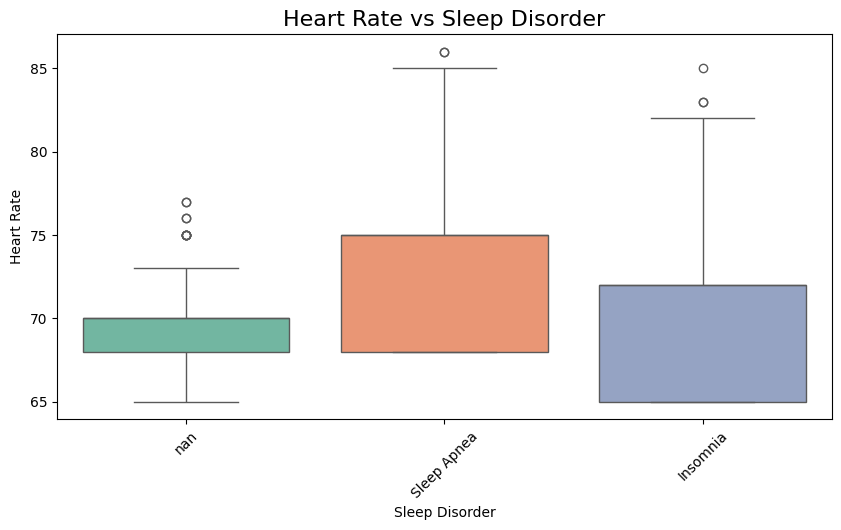

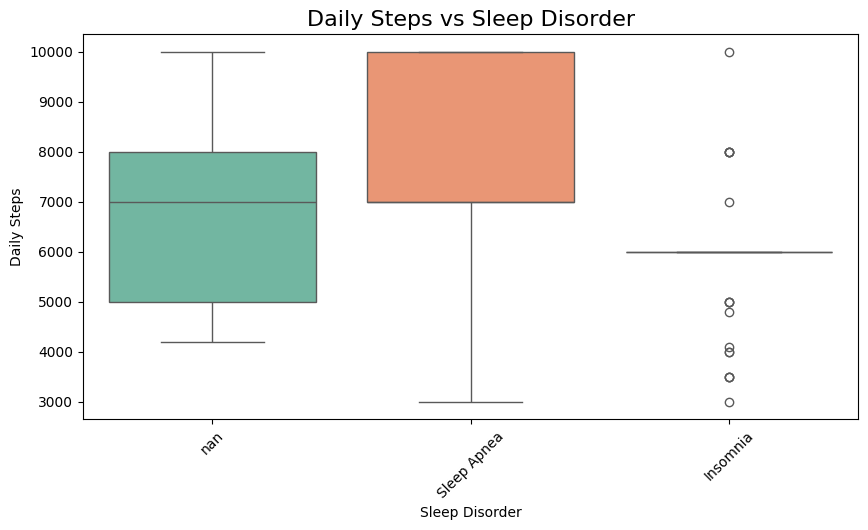

In [ ]:
# Convert Sleep Disorder to categorical
df['Sleep Disorder'] = df['Sleep Disorder'].astype(str)

# Ensure all numerical features are numeric
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']
df[numerical_features] = df[numerical_features].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing numerical values for boxplots
df_box = df.dropna(subset=numerical_features + ['Sleep Disorder'])

# Boxplots of numerical features vs Sleep Disorder
for feature in numerical_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_box, x='Sleep Disorder', y=feature, palette='Set2')
    plt.title(f'{feature} vs Sleep Disorder', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()

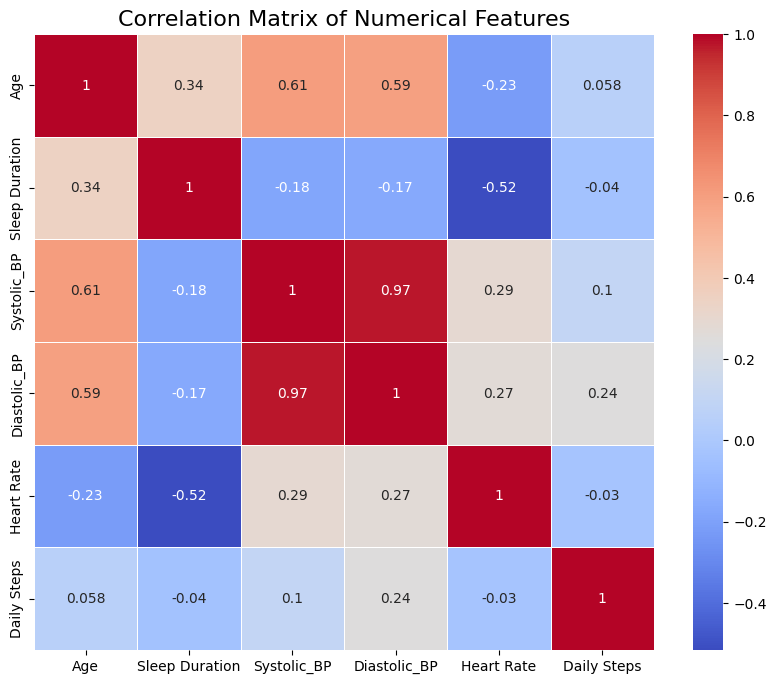

In [ ]:
# Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)

# Update numerical features
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']

# Correlation Heatmap
plt.figure(figsize=(10,8))
numerical_df = df[numerical_features]
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

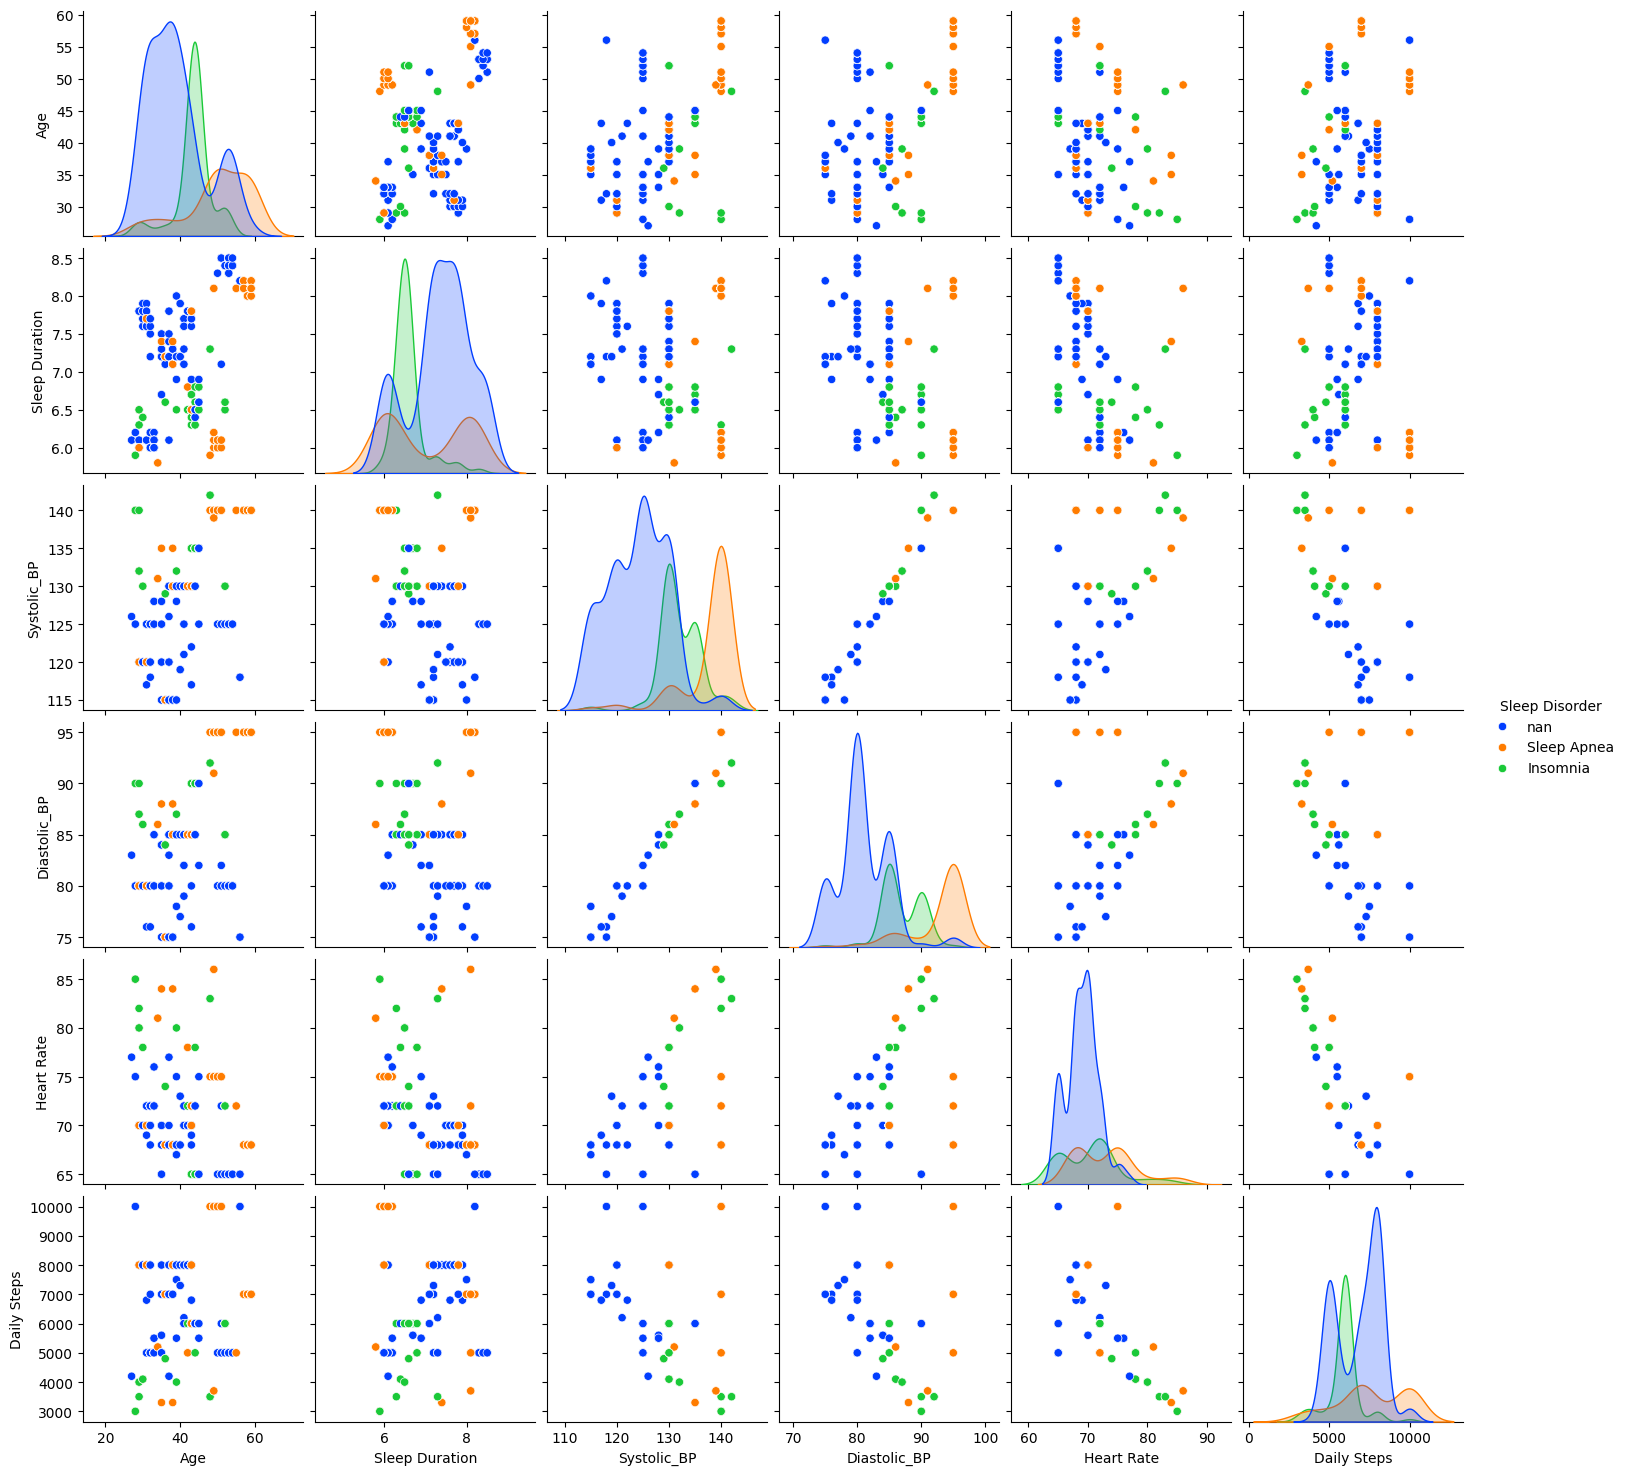

In [ ]:
sns.pairplot(df[numerical_features + ['Sleep Disorder']], hue='Sleep Disorder', palette='bright')
plt.show()

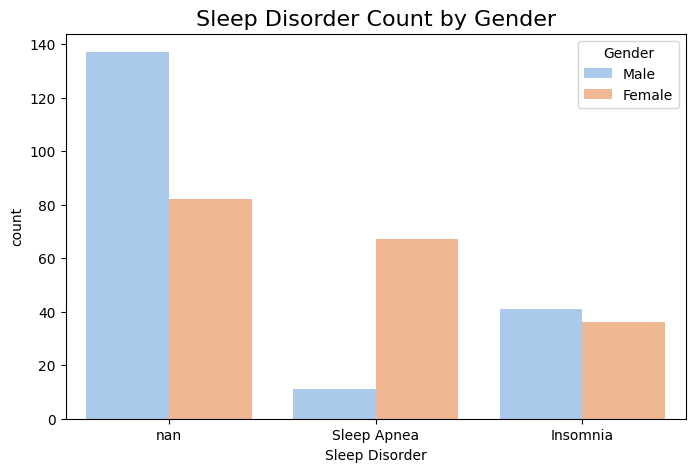

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sleep Disorder', hue='Gender', palette='pastel')
plt.title('Sleep Disorder Count by Gender', fontsize=16)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')
numeric_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
categorical_features = ['Gender', 'Occupation', 'Quality of Sleep',
                        'Physical Activity Level', 'Stress Level', 'BMI Category']

le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
target_le = LabelEncoder()
df['Sleep Disorder'] = target_le.fit_transform(df['Sleep Disorder'].astype(str))
X = df[numeric_features + categorical_features]
y = df['Sleep Disorder']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC()
}

accuracy_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_dict[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 88.00%
Decision Tree Accuracy: 89.33%
Random Forest Accuracy: 88.00%
Gradient Boosting Accuracy: 88.00%
K-Nearest Neighbors Accuracy: 88.00%
Support Vector Machine Accuracy: 89.33%


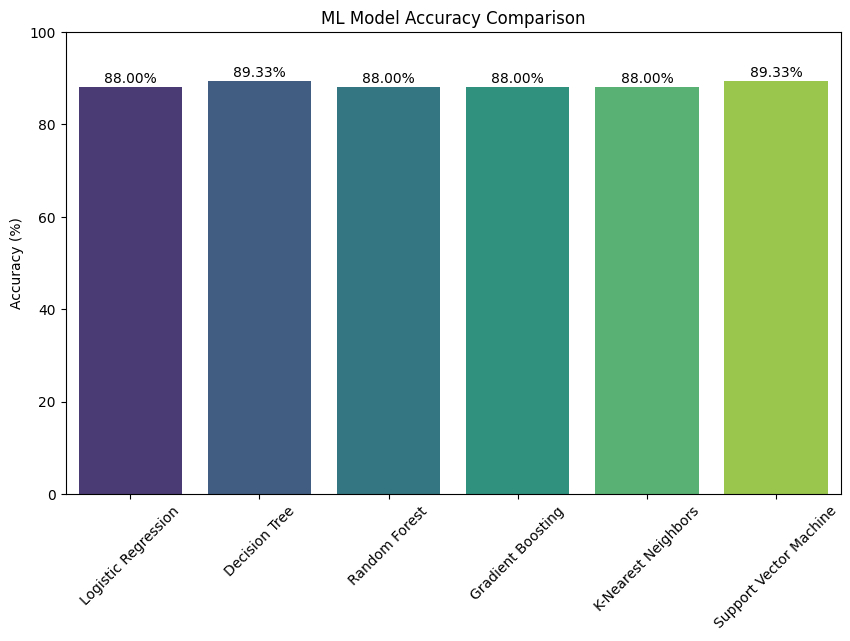

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.ylabel('Accuracy (%)')
plt.title('ML Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(accuracy_dict.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.show()